In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

from func_data_prep import process_string

plt.rcParams['font.family'] = 'Arial'

from pingouin import partial_corr

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

/Users/rohansingh/miniconda3/envs/openai_di/lib/python3.11/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
min_energy_threshold = 50

## Load Metadata

In [ ]:
meta = pd.read_csv("../data/fay_meta_diets.csv")  

meta["start_date"] = pd.to_datetime(meta["start_date"])

print(meta.shape)

(978, 194)


In [ ]:
hei_df = pd.read_csv("../data/HEI_and_dailyHEI.csv")
meta = meta.merge(hei_df, on="subject_key", how="left")

In [5]:
meta["HEI_Quartile"] = pd.Categorical(
    meta["HEI_Quartile"], categories=["Q1", "Q2", "Q3", "Q4"], ordered=True
)
meta["daily_HEI_Quartile"] = pd.Categorical(
    meta["daily_HEI_Quartile"], categories=["Q1", "Q2", "Q3", "Q4"], ordered=True
)

meta["bmi_cat"] = pd.Categorical(
    meta["bmi_cat"],
    categories=["Underweight", "Normal", "Overweight", "Obese"],
    ordered=True,
)
meta["age_group_2"] = pd.Categorical(
    meta["age_group_2"], categories=["<35", "35-50", ">50"], ordered=True
)

## Load Merged Meals Data

In [6]:
merged_meals = pd.read_pickle("../data/merged_log_iauc.pkl")  ## From PPGR paper

merged_meals["eaten_at"] = pd.to_datetime(merged_meals["eaten_at"])
merged_meals["local_eaten_at"] = pd.to_datetime(merged_meals["local_eaten_at"])

merged_meals["eaten_date"] = merged_meals["eaten_at"].dt.date

# Extract the hour from 'local_eaten_at'
merged_meals["eaten_hour"] = merged_meals["local_eaten_at"].dt.hour

# Add cohort info to merged meals
merged_meals = merged_meals.merge(
    meta[["subject_key", "cohort", "start_date"]],
    left_on="subject_key",
    right_on="subject_key",
    how="inner",
)

print(merged_meals.shape)

(96061, 92)


#### Filter Low Energy Dates and Users

In [7]:
def filter_low_energy_dates_and_users(df, energy_threshold=1000, min_valid_days=5):
    """
    Filter out dates where the total energy intake is below a specified threshold for each user,
    and remove users with less than a specified number of valid days.

    Parameters:
    df (pandas.DataFrame): The input DataFrame containing meal data.
    energy_threshold (int): The minimum total energy intake per day (default is 1000 kcal).
    min_valid_days (int): The minimum number of valid days required for a user (default is 5).

    Returns:
    pandas.DataFrame: A filtered DataFrame with low-energy dates and users with insufficient valid days removed.
    """
    # Calculate total energy intake per day for each user
    daily_energy = df.groupby(["subject_key", "eaten_date"])["energy_kcal_eaten"].sum()

    # Create a boolean mask for days with energy intake above the threshold
    valid_days = daily_energy >= energy_threshold

    # Count the number of valid days for each user
    valid_day_counts = valid_days.groupby("subject_key").sum()

    # Create a mask for users with sufficient valid days
    valid_users = valid_day_counts >= min_valid_days

    # Filter the original DataFrame based on valid days and users
    filtered_df = df[
        (
            df.set_index(["subject_key", "eaten_date"]).index.isin(
                valid_days[valid_days].index
            )
        )
        & (df["subject_key"].isin(valid_users[valid_users].index))
    ]

    return filtered_df

In [8]:
def filter_low_energy_dates_and_users_with_max_days(
    df, energy_threshold=1000, min_valid_days=5
):
    """
    Filter out dates where the total energy intake is below a specified threshold for each user,
    and remove users with less than a specified number of valid days. Select up to max_days
    continuous days for each user based on their cohort (14 days for cohort_B, 28 days for cohort_C).

    Parameters:
    df (pandas.DataFrame): The input DataFrame containing meal data.
    energy_threshold (int): The minimum total energy intake per day (default is 1000 kcal).
    min_valid_days (int): The minimum number of valid days required for a user (default is 5).

    Returns:
    pandas.DataFrame: A filtered DataFrame with low-energy dates and users with insufficient
                     valid days removed, including only up to max_days continuous days per user.
    """
    # Calculate total energy intake per day for each user
    daily_energy = df.groupby(["subject_key", "eaten_date"])["energy_kcal_eaten"].sum()

    # Create a boolean mask for days with energy intake above the threshold
    valid_days = daily_energy >= energy_threshold

    # Count the number of valid days for each user
    valid_day_counts = valid_days.groupby("subject_key").sum()

    # Create a mask for users with sufficient valid days
    valid_users = valid_day_counts >= min_valid_days

    # Initialize container for valid date ranges
    valid_date_ranges = []

    # Process each valid user
    for user in valid_users[valid_users].index:
        # Get user's cohort and set appropriate max_days
        user_cohort = df[df["subject_key"] == user]["cohort"].iloc[0]
        max_days = 14 if user_cohort == "cohort_b" else 28

        user_days = valid_days[user]
        user_days = user_days[user_days].index  # Get only valid dates

        if len(user_days) == 0:
            continue

        # Sort dates to ensure continuity check works correctly
        user_days = sorted(user_days)

        # Find the longest continuous sequence of valid days
        best_start = 0
        current_start = 0
        current_length = 1
        max_length = 1

        for i in range(1, len(user_days)):
            if (user_days[i] - user_days[i - 1]).days == 1:
                current_length += 1
                if current_length > max_length:
                    max_length = current_length
                    best_start = current_start
            else:
                current_length = 1
                current_start = i

        # Select the continuous range, limited by max_days
        start_date = user_days[best_start]
        end_date = user_days[
            min(best_start + max_days - 1, best_start + max_length - 1)
        ]

        valid_date_ranges.append((user, start_date, end_date))

    # Filter the original DataFrame based on valid users and their date ranges
    filtered_df = df[
        df.apply(
            lambda row: any(
                user == row["subject_key"]
                and start_date <= row["eaten_date"] <= end_date
                for user, start_date, end_date in valid_date_ranges
            ),
            axis=1,
        )
    ]

    return filtered_df

In [9]:
def filter_low_energy_dates_and_users_with_max_days_from_start_date(
    df, energy_threshold=1000, min_valid_days=5
):
    """
    Filter out dates where the total energy intake is below a specified threshold for each user,
    select continuous days from start_date based on cohort (14 days for cohort_B, 28 days for cohort_C),
    and remove users with less than the specified number of valid days in their continuous period.

    Parameters:
    df (pandas.DataFrame): The input DataFrame containing meal data with columns:
                          subject_key, eaten_date, energy_kcal_eaten, cohort, start_date
    energy_threshold (int): The minimum total energy intake per day (default is 1000 kcal).
    min_valid_days (int): The minimum number of valid days required for a user in their
                         continuous period (default is 5).

    Returns:
    pandas.DataFrame: A filtered DataFrame with low-energy dates removed and only users with
                     sufficient valid days in their continuous period included.
    """
    # Calculate total energy intake per day for each user
    daily_energy = df.groupby(["subject_key", "eaten_date"])["energy_kcal_eaten"].sum()

    # Create a boolean mask for days with energy intake above the threshold
    valid_days = daily_energy >= energy_threshold

    # Initialize container for valid date ranges
    valid_date_ranges = []

    # Process each user
    for user in valid_days.index.get_level_values("subject_key").unique():
        # Get user's cohort and set appropriate max_days
        user_data = df[df["subject_key"] == user].iloc[0]
        user_cohort = user_data["cohort"]
        start_date = user_data["start_date"]
        max_days = 14 if user_cohort == "cohort_b" else 28

        # Get valid days for this user starting from start_date
        user_days = valid_days[user]
        user_days = user_days[user_days].index  # Get only valid dates
        # Convert start_date to pandas Timestamp if it isn't already
        start_date_ts = pd.Timestamp(start_date)
        user_days = [
            d for d in user_days if pd.Timestamp(d) >= start_date_ts
        ]  # Filter dates from start_date

        if len(user_days) == 0:
            continue

        # Sort dates to ensure continuity check works correctly
        user_days = sorted(user_days)

        # Find the longest continuous sequence of valid days
        best_start = 0
        current_start = 0
        current_length = 1
        max_length = 1

        for i in range(1, len(user_days)):
            if (user_days[i] - user_days[i - 1]).days == 1:
                current_length += 1
                if current_length > max_length:
                    max_length = current_length
                    best_start = current_start
            else:
                current_length = 1
                current_start = i

        # Select the continuous range, limited by max_days
        start_idx = best_start
        end_idx = min(best_start + max_days - 1, best_start + max_length - 1)

        # Only include the date range if it starts from or after the start_date
        # and has minimum number of valid days
        if pd.Timestamp(user_days[start_idx]) >= start_date_ts:
            continuous_period_length = end_idx - start_idx + 1
            if continuous_period_length >= min_valid_days:
                valid_date_ranges.append(
                    (user, user_days[start_idx], user_days[end_idx])
                )

    # Filter the original DataFrame based on valid users and their date ranges
    filtered_df = df[
        df.apply(
            lambda row: any(
                user == row["subject_key"]
                and start_date <= row["eaten_date"] <= end_date
                for user, start_date, end_date in valid_date_ranges
            ),
            axis=1,
        )
    ]

    return filtered_df

In [10]:
# merged_meals = filter_low_energy_dates_and_users(
#     merged_meals,
#     energy_threshold=250,
#     min_valid_days=5,
# )

# merged_meals = filter_low_energy_dates_and_users_with_max_days(
#     merged_meals,
#     energy_threshold=250,
#     min_valid_days=5,
# )

merged_meals = filter_low_energy_dates_and_users_with_max_days_from_start_date(
    merged_meals,
    energy_threshold=500,
    min_valid_days=5,
)

In [11]:
print(
    merged_meals.groupby("subject_key")["eaten_date"]
    .nunique()
    .sort_values(ascending=False)
    .sum()
)

13387


#### Remove Liquid Only Dishes

In [12]:
def remove_liquid_only_dishes(row):
    for i in row["eaten_unit"]:
        if i in ["g", "kg"]:
            return True
    return False


merged_meals = merged_meals[merged_meals.apply(remove_liquid_only_dishes, axis=1)]
merged_meals.shape

(71823, 92)

### Assign Meal Types

In [13]:
def assign_meal_type(time):
    """
    Assign meal type based on the given time.

    Args:
    time (datetime.time): The time of the meal.

    Returns:
    str: The assigned meal type ('Breakfast', 'Lunch', 'Dinner', or 'Other').
    """
    if time.hour >= 5 and time.hour < 11:
        return "Breakfast"
    elif time.hour >= 11 and time.hour < 16:
        return "Lunch"
    elif time.hour >= 16 and time.hour < 23:
        return "Dinner"
    else:
        return "Late_night"


merged_meals["meal_type"] = merged_meals["local_eaten_at"].apply(assign_meal_type)

## Frequency of EO

In [14]:
temp1 = merged_meals.copy()
temp1 = temp1[temp1["energy_kcal_eaten"] > min_energy_threshold]

## Remove Standardised Meals
# temp1 = temp1[~(temp1['combined_name'].apply(lambda x: 'Tag standardised meal' in x))]

eo_freq = (
    temp1.groupby("subject_key")["eaten_date"]
    .apply(lambda x: x.groupby(x).count().mean())
    .sort_values(ascending=False)
)
eo_freq = eo_freq.to_frame(name="eo_freq").reset_index()

In [15]:
print("Before meta shape", meta.shape)
meta = meta.merge(eo_freq, left_on="subject_key", right_on="subject_key", how="inner")
print("After meta shape", meta.shape)

Before meta shape (978, 198)
After meta shape (962, 199)


## Spacing of EO

In [16]:
def calculate_average_eaten_time_diff_for_user_per_day(
    df, time_col="local_eaten_at", date_col="eaten_date"
):
    # Convert time_col to datetime if it's not already
    df[time_col] = pd.to_datetime(df[time_col])

    # Sort the dataframe by subject_key, date, and eaten_at
    df_sorted = df.sort_values(["subject_key", date_col, time_col])

    # Group by subject_key and date, then calculate time differences
    time_diffs = df_sorted.groupby(["subject_key", date_col])[time_col].diff()

    # Convert time differences to hours
    time_diffs_hours = time_diffs.dt.total_seconds() / 3600

    # Calculate average time difference for each user
    avg_time_diffs = time_diffs_hours.groupby(df_sorted["subject_key"]).mean()

    return avg_time_diffs

In [17]:
eo_space = calculate_average_eaten_time_diff_for_user_per_day(merged_meals)

print("Before meta shape", meta.shape)
meta = meta.merge(
    eo_space.to_frame(name="eo_space"),
    left_on="subject_key",
    right_index=True,
    how="inner",
)
print("After meta shape", meta.shape)

meta.corr(numeric_only=True)["eo_space"].sort_values(ascending=False)

Before meta shape (962, 199)
After meta shape (962, 200)


eo_space                       1.000000
mean_simpson_diversity_kcal    0.347971
CV_sugar_eaten                 0.341938
CV_fruits_fg_eaten             0.275804
CV_sugary_fg_eaten             0.246832
                                 ...   
mean_dds                      -0.356229
energy_kcal_eaten             -0.364493
energy_kj_eaten               -0.365163
sugar_eaten                   -0.393276
eo_freq                       -0.772312
Name: eo_space, Length: 140, dtype: float64

## Meal Type Skip Ratios

In [18]:
def count_meal_types(df):
    # Group by date and meal type, then count
    meal_counts = df.groupby(["eaten_date", "meal_type"]).size().unstack(fill_value=0)

    # Ensure all meal types are present
    all_meal_types = ["Breakfast", "Lunch", "Dinner", "Late_night"]
    for meal_type in all_meal_types:
        if meal_type not in meal_counts.columns:
            meal_counts[meal_type] = 0

    # Reorder columns to have a consistent order
    meal_counts = meal_counts[all_meal_types]

    # Calculate the ratio of zeros in each column to the number of rows
    zero_ratios = (meal_counts == 0).mean()

    # Mean number of meals per meal type
    mean_meal_counts = meal_counts.mean()

    # Combine zero_ratios and mean_meal_counts into a single DataFrame
    meal_stats = pd.DataFrame(
        {"zero_ratio": zero_ratios, "mean_count": mean_meal_counts}
    )

    # return meal_counts, meal_stats
    return zero_ratios

In [19]:
meal_type_skip_ratios = merged_meals.groupby("subject_key").apply(count_meal_types)

meal_type_skip_ratios.columns = [
    c + "_skip_ratio" for c in meal_type_skip_ratios.columns
]
meal_type_skip_ratios.reset_index(inplace=True)

print(meta.shape)
meta = meta.merge(
    meal_type_skip_ratios, left_on="subject_key", right_on="subject_key", how="inner"
)
print(meta.shape)

(962, 200)
(962, 204)


/var/folders/kl/wv2_2q3n4z3d2bxtztx97rgc0000gn/T/ipykernel_72647/2109582551.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  meal_type_skip_ratios = merged_meals.groupby("subject_key").apply(count_meal_types)


## Save the new meta

In [20]:
meta.to_csv("../data/meta_meal_patterns.csv", index=False)

In [21]:
meta["eo_freq"].describe()

count    962.000000
mean       4.910623
std        0.964997
min        2.125000
25%        4.250000
50%        4.846154
75%        5.500000
max        8.857143
Name: eo_freq, dtype: float64

In [22]:
plt.figure(figsize=(5, 3))
plt.hist(meta["eo_freq"], bins=20, alpha=0.7, color="lightblue", edgecolor="black")
plt.xlabel("Eating Occasions per Day")
plt.ylabel("Frequency")
plt.title(f"Distribution of EO Frequency (threshold={min_energy_threshold})")

# Calculate mean and standard deviation
mean_eo = meta["eo_freq"].mean()
std_eo = meta["eo_freq"].std()

# Add text to the plot
plt.text(
    0.98,
    0.95,
    f"Mean = {mean_eo:.2f}\nSD = {std_eo:.2f}",
    ha="right",
    va="top",
    transform=plt.gca().transAxes,
    fontsize=10,
    bbox=dict(facecolor="white", alpha=0.7, edgecolor="gray"),
)

plt.savefig(
    f"../images/supplementary/eo_freq_distribution_at_{min_energy_threshold}kcal.png",
    bbox_inches="tight",
    dpi=300,
)
plt.close()

### at 50 kcal threshold
mean       4.91
std        0.96

### at 100 kcal threshold
mean       4.43
std        0.78

## Merge Merged meals with Meta

In [23]:
merged_meals_with_meta = merged_meals.merge(
    meta.drop(columns=[i for i in meta.columns if "eaten" in i]),
    left_on="subject_key",
    right_on="subject_key",
    how="inner",
)

merged_meals_with_meta = merged_meals_with_meta[
    merged_meals_with_meta["energy_kcal_eaten"] > min_energy_threshold
]

In [24]:
merged_meals_with_meta.to_pickle("../data/merged_meals_with_meta.pkl")

In [25]:
merged_meals_with_meta.shape

(65838, 205)

In [26]:
merged_meals_with_meta.groupby("subject_key")["eaten_date"].nunique().sum()

13387

## EO Frequency Weekend Diff

In [27]:
temp1["eaten_date"] = pd.to_datetime(temp1["eaten_date"])
temp1["hour"] = temp1["eaten_date"].dt.hour
temp1["day_of_week"] = temp1["eaten_date"].dt.dayofweek
# temp1['is_weekend'] = temp1.apply(
#     lambda row: 'Weekend' if (row['day_of_week'] == 5 and row['hour'] >= 18) or row['day_of_week'] >= 6 else 'Weekday',
#     axis=1)

temp1["is_weekend"] = temp1["day_of_week"].apply(
    lambda x: "Weekend" if x in [5, 6] else "Weekday"
)

eo_freq_weekend = temp1.groupby(["subject_key", "is_weekend"])["eaten_date"].apply(
    lambda x: x.groupby(x).count().mean()
)
eo_freq_weekend = eo_freq_weekend.to_frame(name="eo_freq").reset_index().round(2)

eo_freq_weekend = eo_freq_weekend.pivot(
    index="subject_key", columns="is_weekend", values="eo_freq"
)
eo_freq_weekend["diff"] = eo_freq_weekend["Weekend"] - eo_freq_weekend["Weekday"]
eo_freq_weekend.sort_values(by="diff", ascending=False)
eo_freq_weekend_meta = eo_freq_weekend.merge(
    meta, left_index=True, right_on="subject_key", how="inner"
)
eo_freq_weekend_meta.drop(columns=["Weekend", "Weekday"]).corr(
    method="spearman", numeric_only=True
)["diff"].sort_values(ascending=False)

diff                       1.000000
CV_energy_kj_eaten         0.134109
CV_energy_kcal_eaten       0.123531
CV_protein_eaten           0.122998
CV_carb_eaten              0.109057
                             ...   
CV_water_fg_eaten         -0.057057
menstrual_cycle_variety   -0.057468
CV_alcohol_eaten          -0.063084
antibiotics_treatment     -0.078992
CV_vegetables_fg_eaten    -0.081223
Name: diff, Length: 145, dtype: float64

In [28]:
from scipy import stats
from itertools import combinations
from statsmodels.stats.multitest import multipletests


def plot_boxplot_with_stats(data, x, y, ax=None, title=None):
    """
    Create a boxplot with statistical annotations.

    Parameters:
    -----------
    data : pandas.DataFrame
        Input data
    x : str
        Column name for x-axis categories
    y : str
        Column name for y-axis values
    ax : matplotlib.axes.Axes, optional
        The axes to plot on. If None, current axes will be used
    title : str, optional
        Title for the plot

    Returns:
    --------
    matplotlib.axes.Axes
        The annotated axes
    """
    if ax is None:
        ax = plt.gca()

    # Create boxplot
    sns.boxplot(
        x=x,
        y=y,
        data=data,
        ax=ax,
        palette="Set2",
        width=0.24,
        linewidth=0.5,
        fliersize=2,
    )

    # Get categories and perform global test
    categories = data[x].unique()

    # If only two categories, perform Mann-Whitney U test
    if len(categories) == 2:
        stat, global_p = stats.mannwhitneyu(
            data[data[x] == categories[0]][y],
            data[data[x] == categories[1]][y],
            alternative="two-sided",
        )
    else:
        # Perform Kruskal-Wallis test
        groups = [group[y].values for name, group in data.groupby(x)]
        stat, global_p = stats.kruskal(*groups)

    # Get plot dimensions for annotation positioning
    y_max = data[y].max()
    y_min = data[y].min()
    y_range = y_max - y_min
    spacing = y_range * 0.1

    # Only proceed with pairwise tests if global test is significant
    if global_p < 0.05:
        pairs = list(combinations(categories, 2))
        p_values = []
        effect_sizes = []

        # Perform pairwise comparisons
        for cat1, cat2 in pairs:
            data1 = data[data[x] == cat1][y]
            data2 = data[data[x] == cat2][y]

            statistic, p_value = stats.mannwhitneyu(
                data1, data2, alternative="two-sided"
            )
            p_values.append(p_value)

            # Calculate effect size
            n1, n2 = len(data1), len(data2)
            z_score = statistic - (n1 * n2 / 2)
            z_score = z_score / np.sqrt((n1 * n2 * (n1 + n2 + 1)) / 12)
            effect_size = abs(z_score / np.sqrt(n1 + n2))
            effect_sizes.append(effect_size)

        # Multiple comparison correction
        if len(p_values) > 1:
            rejected, p_values_corrected, _, _ = multipletests(
                p_values, method="fdr_bh"
            )
        else:
            p_values_corrected = p_values
            rejected = [p < 0.05 for p in p_values]

        # Add annotations for significant comparisons
        for idx, ((cat1, cat2), p_value, effect_size, is_sig) in enumerate(
            zip(pairs, p_values_corrected, effect_sizes, rejected)
        ):
            if is_sig:
                x1 = np.where(categories == cat1)[0][0]
                x2 = np.where(categories == cat2)[0][0]
                y = y_max + spacing * (idx + 2) + idx

                p_text = "p < 0.001" if p_value < 0.001 else f"p = {p_value:.3f}"
                # stat_text = f'{p_text}\nr = {effect_size:.2f}'
                stat_text = f"{p_text}"

                # Add bracket
                ax.plot(
                    [x1, x1, x2, x2],
                    [y - spacing / 0.5, y - 1, y - 1, y - spacing / 0.5],
                    color="black",
                    linewidth=1,
                )
                ax.text(
                    (x1 + x2) / 2,
                    y - spacing,
                    stat_text,
                    ha="center",
                    va="bottom",
                    color="black",
                )

        # Add global test result
        if len(categories) == 2:
            global_text = (
                f"Mann-Whitney U test: p = {global_p:.3f}"
                if global_p >= 0.001
                else "Mann-Whitney U test: p < 0.001"
            )
        else:
            global_text = (
                f"Kruskal-Wallis test: p = {global_p:.3f}"
                if global_p >= 0.001
                else "Kruskal-Wallis test: p < 0.001"
            )
        ax.text(
            len(categories) / 2 - 0.5,
            y + spacing * 1,
            global_text,
            ha="center",
            va="bottom",
            color="black",
            fontweight="normal",
            fontstyle="italic",
        )

        ax.set_ylim(y_min - y_range * 0.1, y_max + spacing * (len(pairs) + 3))
    else:
        ax.set_ylim(y_min - y_range * 0.1, y_max + spacing * 3)

    if title:
        ax.set_title(title)

    return ax

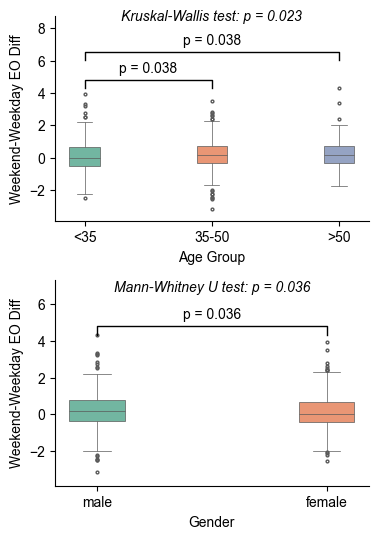

In [29]:
fig, ax = plt.subplots(nrows=2, figsize=(4, 5.5))
ax1 = plot_boxplot_with_stats(
    data=eo_freq_weekend_meta, x="age_group_2", y="diff", ax=ax[0], title=""
)
ax1.set_ylabel("Weekend-Weekday EO Diff")
ax1.set_xlabel(process_string("age_group_2"))

ax2 = plot_boxplot_with_stats(
    data=eo_freq_weekend_meta, x="gender", y="diff", ax=ax[1], title=""
)
ax2.set_ylabel("Weekend-Weekday EO Diff")
ax2.set_xlabel(process_string("gender"))
sns.despine()
plt.tight_layout()

fig.savefig("../images/fig3/eo_freq_weekend_diff.png", dpi=300, bbox_inches="tight")